In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/papers.csv")

print(df.shape)


(500, 7)


In [2]:
import ast

def reconstruct_abstract(inverted_index):

    if pd.isna(inverted_index):
        return ""

    inverted_index = ast.literal_eval(inverted_index)

    words = []

    for word, positions in inverted_index.items():
        for position in positions:
            words.append((position, word))

    words.sort()

    return " ".join(word for position, word in words)


In [3]:
df["abstract_text"] = df["abstract"].apply(reconstruct_abstract)


In [4]:
df["text"] = df["title"] + " " + df["abstract_text"]


In [5]:
print(df["text"].iloc[0])


Retrieval-Augmented Generation for Large Language Models: A Survey Large Language Models (LLMs) showcase impressive capabilities but encounter challenges like hallucination, outdated knowledge, and non-transparent, untraceable reasoning processes. Retrieval-Augmented Generation (RAG) has emerged as a promising solution by incorporating knowledge from external databases. This enhances the accuracy and credibility of the generation, particularly for knowledge-intensive tasks, and allows for continuous knowledge updates and integration of domain-specific information. RAG synergistically merges LLMs' intrinsic knowledge with the vast, dynamic repositories of external databases. This comprehensive review paper offers a detailed examination of the progression of RAG paradigms, encompassing the Naive RAG, the Advanced RAG, and the Modular RAG. It meticulously scrutinizes the tripartite foundation of RAG frameworks, which includes the retrieval, the generation and the augmentation techniques. 

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = vectorizer.fit_transform(df["text"])


In [7]:
print(tfidf_matrix.shape)


(500, 5000)


In [8]:
terms = vectorizer.get_feature_names_out()

print(terms[:50])


['000' '00001' '001' '002' '006' '007' '008' '01' '012' '013' '016' '02'
 '03' '032' '04' '05' '08' '10' '100' '1000' '11' '12' '128' '13' '14'
 '15' '16' '17' '175b' '18' '1894' '19' '1b' '20' '200' '2000' '2020'
 '2021' '2022' '2023' '2024' '2025' '22' '23' '24' '25' '26' '27' '28'
 '282']


In [9]:
import numpy as np

scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

top_indices = scores.argsort()[-20:][::-1]

for i in top_indices:
    print(terms[i], scores[i])


rag 0.06826996808151832
retrieval 0.06793312799889505
generation 0.058227137379376716
augmented 0.04835498981933648
knowledge 0.03956746794976007
llms 0.03402058601140503
language 0.03141913662127934
models 0.03092983309993997
based 0.025833931936547847
large 0.025749643755472413
data 0.024492900113916728
information 0.023962543035240782
model 0.023486532573989895
systems 0.02246042772868084
llm 0.021487266982572667
graph 0.019668184493129123
performance 0.019485967056653865
framework 0.01942373313994767
question 0.019001646992337213
context 0.018991800291617688


In [10]:
from sklearn.metrics.pairwise import cosine_similarity


In [11]:
similarity_matrix = cosine_similarity(tfidf_matrix)

print(similarity_matrix.shape)


(500, 500)


In [12]:
paper_index = 0


In [13]:
similarities = similarity_matrix[paper_index]


In [14]:
similar_indices = similarities.argsort()[::-1]


In [15]:
similar_indices = similar_indices[1:6]


In [16]:
for index in similar_indices:
    print("Title:", df.iloc[index]["title"])
    print("Similarity:", similarities[index])
    print()


Title: A Survey on Retrieval-Augmented Text Generation for Large Language Models
Similarity: 0.26851454042775186

Title: A Research of Challenges and Solutions in Retrieval Augmented Generation (RAG) Systems
Similarity: 0.24790846507561634

Title: A Survey on RAG Meeting LLMs: Towards Retrieval-Augmented Large Language Models
Similarity: 0.2350392993644736

Title: Retrieval augmented generation for large language models in healthcare: A systematic review
Similarity: 0.2340939346046771

Title: A Comprehensive Survey of Retrieval-Augmented Generation (RAG): Evolution, Current Landscape and Future Directions
Similarity: 0.2298714348737726



In [17]:
paper_index = 0

print("SELECTED PAPER:")
print(df.iloc[paper_index]["title"])
print()

similarities = similarity_matrix[paper_index]

similar_indices = similarities.argsort()[::-1][1:6]

print("MOST SIMILAR PAPERS:\n")

for rank, index in enumerate(similar_indices, start=1):
    print(f"{rank}. {df.iloc[index]['title']}")
    print(f"   Similarity: {similarities[index]:.3f}")
    print()


SELECTED PAPER:
Retrieval-Augmented Generation for Large Language Models: A Survey

MOST SIMILAR PAPERS:

1. A Survey on Retrieval-Augmented Text Generation for Large Language Models
   Similarity: 0.269

2. A Research of Challenges and Solutions in Retrieval Augmented Generation (RAG) Systems
   Similarity: 0.248

3. A Survey on RAG Meeting LLMs: Towards Retrieval-Augmented Large Language Models
   Similarity: 0.235

4. Retrieval augmented generation for large language models in healthcare: A systematic review
   Similarity: 0.234

5. A Comprehensive Survey of Retrieval-Augmented Generation (RAG): Evolution, Current Landscape and Future Directions
   Similarity: 0.230



In [18]:
from sentence_transformers import SentenceTransformer


In [19]:
model = SentenceTransformer("all-MiniLM-L6-v2")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [20]:
embeddings = model.encode(
    df["text"].tolist(),
    show_progress_bar=True
)


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [21]:
print(embeddings.shape)


(500, 384)


In [22]:
from sklearn.metrics.pairwise import cosine_similarity


In [23]:
embedding_similarity = cosine_similarity(embeddings)


In [24]:
print(embedding_similarity.shape)


(500, 500)


In [25]:
paper_index = 0

similarities = embedding_similarity[paper_index]

similar_indices = similarities.argsort()[::-1][1:6]

print("SELECTED PAPER:")
print(df.iloc[paper_index]["title"])
print()

print("MOST SIMILAR PAPERS:\n")

for rank, index in enumerate(similar_indices, start=1):
    print(f"{rank}. {df.iloc[index]['title']}")
    print(f"   Similarity: {similarities[index]:.3f}")
    print()


SELECTED PAPER:
Retrieval-Augmented Generation for Large Language Models: A Survey

MOST SIMILAR PAPERS:

1. Dynamic and Parametric Retrieval-Augmented Generation
   Similarity: 0.859

2. A Research of Challenges and Solutions in Retrieval Augmented Generation (RAG) Systems
   Similarity: 0.845

3. A Comprehensive Survey of Retrieval-Augmented Generation (RAG): Evolution, Current Landscape and Future Directions
   Similarity: 0.828

4. A Survey on Retrieval-Augmented Text Generation for Large Language Models
   Similarity: 0.803

5. Retrieval-Augmented Generation for AI-Generated Content: A Survey
   Similarity: 0.800



In [26]:
import numpy as np

np.save("../data/processed/paper_embeddings.npy", embeddings)


In [27]:
loaded_embeddings = np.load("../data/processed/paper_embeddings.npy")

print(loaded_embeddings.shape)


(500, 384)


## Clustering Techniques


# Testing K Means(k=5)

In [28]:
from sklearn.cluster import KMeans


In [29]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(embeddings)


In [30]:
print(kmeans_labels[:20])


[1 4 1 4 3 1 1 3 4 4 1 2 1 1 3 3 3 1 2 2]


In [31]:
df["kmeans_cluster"] = kmeans_labels


In [32]:
df["kmeans_cluster"].value_counts().sort_index()


kmeans_cluster
0     48
1    215
2     62
3     92
4     83
Name: count, dtype: int64

In [33]:
for cluster in sorted(df["kmeans_cluster"].unique()):

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*60}")

    cluster_papers = df[df["kmeans_cluster"] == cluster]

    for title in cluster_papers["title"].head(5):
        print("-", title)



CLUSTER 0
- Design and Evaluation of a Retrieval-Augmented Generation Architecture for OWASP Security Data
- The Good and The Bad: Exploring Privacy Issues in Retrieval-Augmented Generation (RAG)
- Enhancing the Precision and Interpretability of Retrieval-Augmented Generation (RAG) in Legal Technology: A Survey
- CyberMetric: A Benchmark Dataset based on Retrieval-Augmented Generation for Evaluating LLMs in Cybersecurity Knowledge
- Web Application for Retrieval-Augmented Generation: Implementation and Testing

CLUSTER 1
- Retrieval-Augmented Generation for Large Language Models: A Survey
- Benchmarking Large Language Models in Retrieval-Augmented Generation
- Improving the Domain Adaptation of Retrieval Augmented Generation (RAG) Models for Open Domain Question Answering
- Evaluating Retrieval Quality in Retrieval-Augmented Generation
- LightRAG: Simple and Fast Retrieval-Augmented Generation

CLUSTER 2
- Interactive AI With Retrieval-Augmented Generation for Next Generation Networki

# elbow method

In [34]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(embeddings)

    inertias.append(kmeans.inertia_)


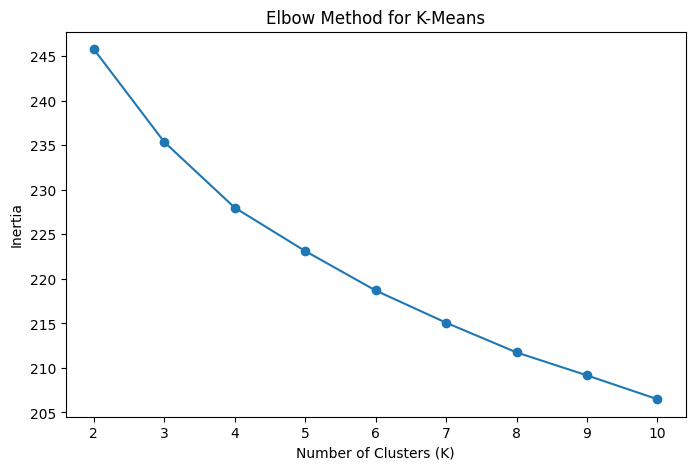

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.show()


# silhouette score

In [36]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(embeddings)

    score = silhouette_score(embeddings, labels)

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")


K = 2, Silhouette Score = 0.0618
K = 3, Silhouette Score = 0.0559
K = 4, Silhouette Score = 0.0633
K = 5, Silhouette Score = 0.0654
K = 6, Silhouette Score = 0.0440
K = 7, Silhouette Score = 0.0483
K = 8, Silhouette Score = 0.0503
K = 9, Silhouette Score = 0.0454
K = 10, Silhouette Score = 0.0447


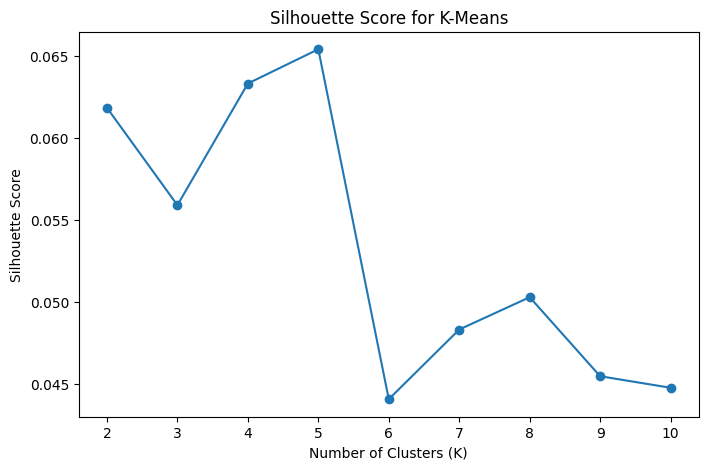

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")

plt.show()


# PCA

In [38]:
from sklearn.decomposition import PCA


In [39]:
pca = PCA(n_components=2, random_state=42)

embeddings_2d = pca.fit_transform(embeddings)

print(embeddings_2d.shape)


(500, 2)


In [40]:
print(pca.explained_variance_ratio_)
print("Total variance explained:",
      pca.explained_variance_ratio_.sum())


[0.06782852 0.05586593]
Total variance explained: 0.12369445


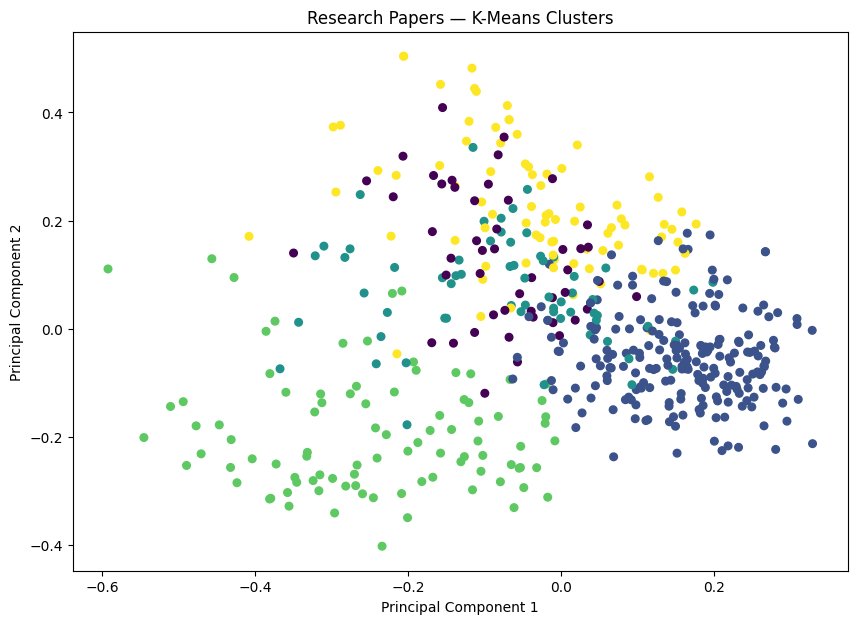

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=kmeans_labels,
    s=30
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Research Papers — K-Means Clusters")

plt.show()


In [42]:
print(embeddings_2d.shape)


(500, 2)


In [43]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())


[0.06782852 0.05586593]
0.12369445


# Agglomerative clustering


In [44]:
from sklearn.cluster import AgglomerativeClustering


In [45]:
agg = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

agg_labels = agg.fit_predict(embeddings)


In [46]:
df["agg_cluster"] = agg_labels

print(df["agg_cluster"].value_counts().sort_index())


agg_cluster
0    131
1     45
2    207
3     35
4     82
Name: count, dtype: int64


In [47]:
from sklearn.metrics import silhouette_score

agg_score = silhouette_score(
    embeddings,
    agg_labels
)

print("Agglomerative Silhouette Score:", agg_score)


Agglomerative Silhouette Score: 0.04128546640276909


In [48]:
for cluster in sorted(df["agg_cluster"].unique()):

    print(f"\n{'='*60}")
    print(f"AGGLOMERATIVE CLUSTER {cluster}")
    print(f"{'='*60}")

    cluster_papers = df[df["agg_cluster"] == cluster]

    for title in cluster_papers["title"].head(5):
        print("-", title)



AGGLOMERATIVE CLUSTER 0
- Evaluation of Retrieval-Augmented Generation: A Survey
- Corrective Retrieval Augmented Generation
- Interactive AI With Retrieval-Augmented Generation for Next Generation Networking
- Retrieval-augmented generation for generative artificial intelligence in health care
- Retrieval-augmented generation for educational application: A systematic survey

AGGLOMERATIVE CLUSTER 1
- Benchmarking Large Language Models in Retrieval-Augmented Generation
- Design and Evaluation of a Retrieval-Augmented Generation Architecture for OWASP Security Data
- The Good and The Bad: Exploring Privacy Issues in Retrieval-Augmented Generation (RAG)
- Benchmarking Large Language Models in Retrieval-Augmented Generation
- Reducing hallucination in structured outputs via Retrieval-Augmented Generation

AGGLOMERATIVE CLUSTER 2
- Retrieval-Augmented Generation for Large Language Models: A Survey
- Improving the Domain Adaptation of Retrieval Augmented Generation (RAG) Models for Open Do

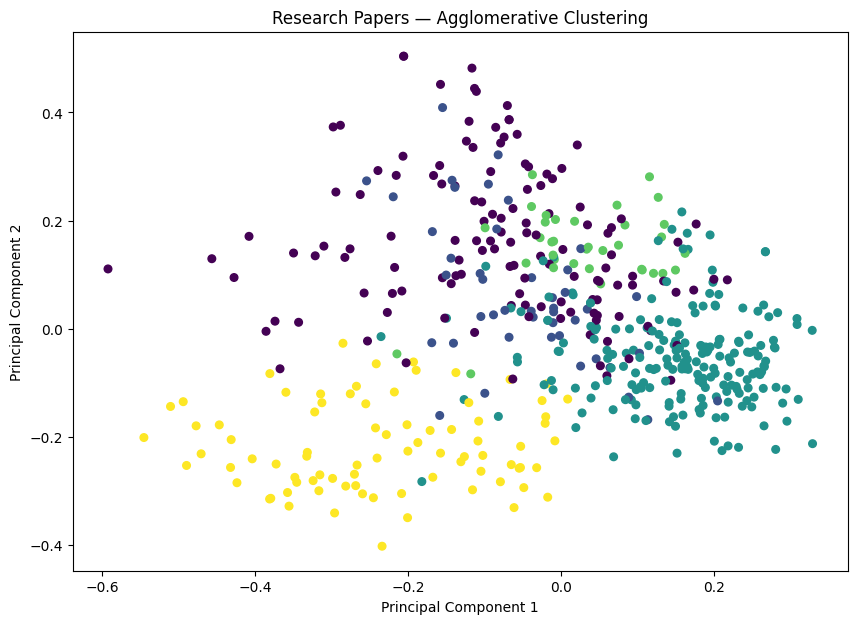

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=agg_labels,
    s=30
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Research Papers — Agglomerative Clustering")

plt.show()


somehow we found that we have some duplicates

In [50]:
duplicates = df[df["title"].duplicated(keep=False)]

print(duplicates[["title", "year"]])
print("Duplicate rows:", len(duplicates))


                                                 title  year
1                Active Retrieval Augmented Generation  2023
2    Benchmarking Large Language Models in Retrieva...  2024
4    Benchmarking Retrieval-Augmented Generation fo...  2024
5    Improving the Domain Adaptation of Retrieval A...  2023
9            Corrective Retrieval Augmented Generation  2025
10   LightRAG: Simple and Fast Retrieval-Augmented ...  2025
13      Graph Retrieval-Augmented Generation: A Survey  2025
17   Seven Failure Points When Engineering a Retrie...  2024
20   Searching for Best Practices in Retrieval-Augm...  2024
21          GRAG: Graph Retrieval-Augmented Generation  2025
22   Retrieval-Augmented Generation for AI-Generate...  2024
23   Retrieval-Augmented Generation for AI-Generate...  2026
27   ARES: An Automated Evaluation Framework for Re...  2024
35   Knowledge Graph-Guided Retrieval Augmented Gen...  2025
41   Retrieval-Augmented Generation (RAG) in Health...  2025
43   The Good and The Ba

In [51]:
duplicates = df[df["title"].duplicated(keep=False)]

print("Number of duplicate rows:", len(duplicates))
print("Number of unique duplicated titles:", duplicates["title"].nunique())

print("\nDuplicated titles:")
print(duplicates["title"].value_counts())


Number of duplicate rows: 54
Number of unique duplicated titles: 27

Duplicated titles:
title
Active Retrieval Augmented Generation                                                                                      2
Benchmarking Large Language Models in Retrieval-Augmented Generation                                                       2
Benchmarking Retrieval-Augmented Generation for Medicine                                                                   2
Improving the Domain Adaptation of Retrieval Augmented Generation (RAG) Models for Open Domain Question Answering          2
Corrective Retrieval Augmented Generation                                                                                  2
LightRAG: Simple and Fast Retrieval-Augmented Generation                                                                   2
Graph Retrieval-Augmented Generation: A Survey                                                                             2
Seven Failure Points When Engin

In [52]:
print("Original shape:", df.shape)

df_clean = df.drop_duplicates(
    subset=["title"],
    keep="first"
).reset_index(drop=True)

print("After removing duplicates:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))


Original shape: (500, 11)
After removing duplicates: (473, 11)
Rows removed: 27


In [53]:
df_clean["text"] = (
    df_clean["title"].fillna("") + " " +
    df_clean["abstract_text"].fillna("")
)


After cleaning

In [54]:
clean_embeddings = model.encode(
    df_clean["text"].tolist(),
    show_progress_bar=True
)


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

In [55]:
print(clean_embeddings.shape)


(473, 384)


In [56]:
import numpy as np

np.save(
    "../data/processed/clean_paper_embeddings.npy",
    clean_embeddings
)


In [57]:
import sklearn

print(sklearn.__version__)


1.7.0


# HBSCAN

In [58]:
from sklearn.cluster import HDBSCAN


In [59]:
hdbscan = HDBSCAN(
    min_cluster_size=10,
    min_samples=5
)

hdb_labels = hdbscan.fit_predict(clean_embeddings)


In [60]:
import numpy as np

unique_labels = set(hdb_labels)

n_clusters = len(unique_labels - {-1})
noise_points = np.sum(hdb_labels == -1)

print("Number of clusters:", n_clusters)
print("Noise points:", noise_points)


Number of clusters: 2
Noise points: 445


In [61]:
from sklearn.metrics import silhouette_score

mask = hdb_labels != -1

if len(set(hdb_labels[mask])) >= 2:
    hdb_score = silhouette_score(
        clean_embeddings[mask],
        hdb_labels[mask]
    )

    print("HDBSCAN Silhouette Score:", hdb_score)
else:
    print("Not enough clusters to calculate silhouette score.")


HDBSCAN Silhouette Score: 0.19095203280448914


In [62]:
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

results = []

for min_cluster_size in [5, 8, 10, 15, 20]:
    
    for min_samples in [2, 3, 5]:
        
        hdb = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples
        )
        
        labels = hdb.fit_predict(clean_embeddings)

        n_clusters = len(set(labels) - {-1})
        noise = np.sum(labels == -1)
        noise_percent = noise / len(labels)

        mask = labels != -1

        if n_clusters >= 2 and mask.sum() > 1:
            score = silhouette_score(
                clean_embeddings[mask],
                labels[mask]
            )
        else:
            score = np.nan

        results.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise": noise,
            "noise_percent": noise_percent,
            "silhouette": score
        })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "silhouette",
    ascending=False
)


,min_cluster_size,min_samples,clusters,noise,noise_percent,silhouette
5,8,5,2,445,0.940803,0.190952
8,10,5,2,445,0.940803,0.190952
13,20,3,2,411,0.868922,0.139368
10,15,3,2,411,0.868922,0.139368
4,8,3,3,411,0.868922,0.137918
7,10,3,3,411,0.868922,0.137918
6,10,2,3,390,0.824524,0.136770
9,15,2,2,387,0.818182,0.128414
12,20,2,2,387,0.818182,0.128414
0,5,2,2,88,0.186047,0.121379


here noise effects

# PCA After Cleaning

In [63]:
from sklearn.decomposition import PCA

pca_50 = PCA(
    n_components=50,
    random_state=42
)

embeddings_pca50 = pca_50.fit_transform(clean_embeddings)

print(embeddings_pca50.shape)

print(
    "Variance explained:",
    pca_50.explained_variance_ratio_.sum()
)


(473, 50)
Variance explained: 0.7260155


In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_pca = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

pca_labels = kmeans_pca.fit_predict(embeddings_pca50)

pca_silhouette = silhouette_score(
    embeddings_pca50,
    pca_labels
)

print("K-Means + PCA(50) Silhouette Score:",
      pca_silhouette)


K-Means + PCA(50) Silhouette Score: 0.09472209215164185


In [65]:
df_clean["pca_cluster"] = pca_labels


In [66]:
for cluster in sorted(df_clean["pca_cluster"].unique()):

    print(f"\n{'='*60}")
    print(f"PCA + K-MEANS CLUSTER {cluster}")
    print(f"{'='*60}")

    cluster_papers = df_clean[
        df_clean["pca_cluster"] == cluster
    ]

    for title in cluster_papers["title"].head(10):
        print("-", title)



PCA + K-MEANS CLUSTER 0
- Interactive AI With Retrieval-Augmented Generation for Next Generation Networking
- Retrieval-augmented generation for educational application: A systematic survey
- Retrieval-Augmented Generation (RAG) Chatbots for Education: A Survey of Applications
- Rag-Fusion: A New Take on Retrieval Augmented Generation
- Agentic Retrieval-Augmented Generation: Advancing AI-Driven Information Retrieval and Processing
- Agentic Retrieval-Augmented Generation: A Survey on Agentic RAG
- Chatbots in Academia: A Retrieval-Augmented Generation Approach for Improved Efficient Information Access
- ChatCNC: Conversational machine monitoring via large language model and real-time data retrieval augmented generation
- RAGVA: Engineering retrieval augmented generation-based virtual assistants in practice
- Developing a computer-based tutor utilizing Generative Artificial Intelligence (GAI) and Retrieval-Augmented Generation (RAG)

PCA + K-MEANS CLUSTER 1
- Design and Evaluation of 

In [67]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca_k_results = []

for k in range(2, 11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(embeddings_pca50)

    score = silhouette_score(
        embeddings_pca50,
        labels
    )

    pca_k_results.append({
        "k": k,
        "silhouette": score
    })

pca_k_results_df = pd.DataFrame(pca_k_results)

print(pca_k_results_df)


    k  silhouette
0   2    0.086478
1   3    0.080669
2   4    0.091598
3   5    0.094722
4   6    0.094947
5   7    0.075267
6   8    0.064543
7   9    0.068965
8  10    0.067420


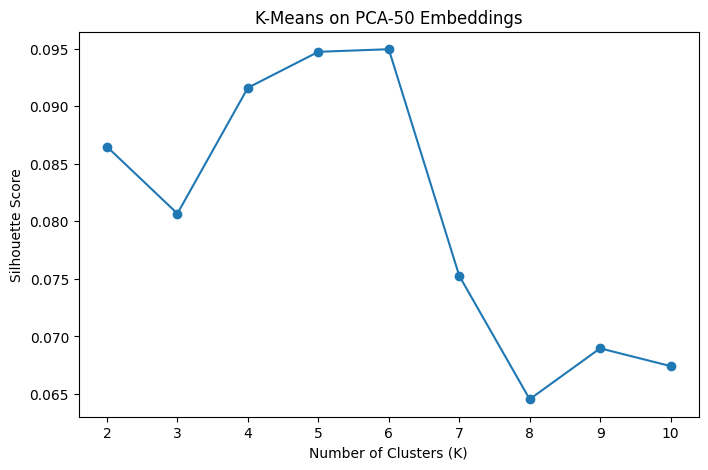

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(
    pca_k_results_df["k"],
    pca_k_results_df["silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means on PCA-50 Embeddings")

plt.show()


In [69]:
from sklearn.metrics.pairwise import cosine_similarity


In [70]:
def search_papers(query, top_k=5):

    # Convert query into embedding
    query_embedding = model.encode([query])

    # Calculate similarity
    similarities = cosine_similarity(
        query_embedding,
        clean_embeddings
    )[0]

    # Get indices of highest similarities
    top_indices = similarities.argsort()[::-1][:top_k]

    # Create results
    results = df_clean.iloc[top_indices].copy()

    results["similarity"] = similarities[top_indices]

    return results


In [71]:
results = search_papers(
    "RAG for healthcare and medical diagnosis",
    top_k=5
)

print(
    results[
        ["title", "year", "citations", "similarity"]
    ].to_string(index=False)
)


                                                                                                                                    title  year  citations  similarity
                                                       RAGChecker: A Fine-grained Framework for Diagnosing Retrieval-Augmented Generation  2024          9    0.516816
Bridging AI and Healthcare: A Scoping Review of Retrieval-Augmented Generation—Ethics, Bias, Transparency, Improvements, and Applications  2025         15    0.495938
                                              Retrieval Augmented Generation for Large Language Models in Healthcare: A Systematic Review  2024         14    0.479772
                                       Enhancing Large Language Models with Retrieval-Augmented Generation: A Radiology-Specific Approach  2025         23    0.476622
       Improving Large Language Model Applications in the Medical and Nursing Domains With Retrieval-Augmented Generation: Scoping Review  2025         22    0.47486

In [72]:
search_papers(
    "RAG for cybersecurity",
    top_k=5
)


,title,year,authors,citations,doi,paper_url,abstract,abstract_text,text,kmeans_cluster,agg_cluster,pca_cluster,similarity
206,MoRSE: Bridging the Gap in Cybersecurity Exper...,2025,"Marco Simoni, Andrea Saracino, P. Vinod, Mauro...",13,https://doi.org/10.1145/3672608.3707898,https://doi.org/10.1145/3672608.3707898,"{'In': [0, 102], 'this': [1, 96], 'paper,': [2...","In this paper, we introduce MoRSE (Mixture of ...",MoRSE: Bridging the Gap in Cybersecurity Exper...,2,1,1,0.528689
177,Advancing TTP Analysis: Harnessing the Power o...,2024,"Reza Fayyazi, Rozhina Taghdimi, Shanchieh Jay ...",22,https://doi.org/10.1109/acsacw65225.2024.00036,https://doi.org/10.1109/acsacw65225.2024.00036,"{'Tactics,': [0], 'Techniques,': [1], 'and': [...","Tactics, Techniques, and Procedures (TTPs) out...",Advancing TTP Analysis: Harnessing the Power o...,0,1,1,0.522317
63,CyberMetric: A Benchmark Dataset based on Retr...,2024,"Norbert Tihanyi, Mohamed Amine Ferrag, Ridhi J...",60,https://doi.org/10.1109/csr61664.2024.10679494,https://doi.org/10.1109/csr61664.2024.10679494,"{'Large': [0], 'Language': [1], 'Models': [2],...",Large Language Models (LLMs) are increasingly ...,CyberMetric: A Benchmark Dataset based on Retr...,0,1,1,0.491820
197,Retrieval Augmented Generation for Robust Cybe...,2024,"M. Shahidur Rahman, Krish Piryani, Aaron Sanch...",11,https://doi.org/10.2172/2474934,https://doi.org/10.2172/2474934,"{'In': [0], 'cybersecurity,': [1], 'the': [2, ...","In cybersecurity, the ability to efficiently a...",Retrieval Augmented Generation for Robust Cybe...,0,1,1,0.489602
38,Design and Evaluation of a Retrieval-Augmented...,2023,"Es, Shahul, Jithin James, Luis Espinosa-Anke, ...",73,https://doi.org/10.48550/arxiv.2309.15217,http://arxiv.org/abs/2309.15217,"{'Project': [0], 'Description': [1], 'This': [...",Project Description This archive contains a re...,Design and Evaluation of a Retrieval-Augmented...,0,1,1,0.464800


In [73]:
results = search_papers(
    "RAG for healthcare and medical diagnosis",
    top_k=5
)

print(
    results[
        ["title", "year", "citations", "similarity"]
    ].to_string(index=False)
)


                                                                                                                                    title  year  citations  similarity
                                                       RAGChecker: A Fine-grained Framework for Diagnosing Retrieval-Augmented Generation  2024          9    0.516816
Bridging AI and Healthcare: A Scoping Review of Retrieval-Augmented Generation—Ethics, Bias, Transparency, Improvements, and Applications  2025         15    0.495938
                                              Retrieval Augmented Generation for Large Language Models in Healthcare: A Systematic Review  2024         14    0.479772
                                       Enhancing Large Language Models with Retrieval-Augmented Generation: A Radiology-Specific Approach  2025         23    0.476622
       Improving Large Language Model Applications in the Medical and Nursing Domains With Retrieval-Augmented Generation: Scoping Review  2025         22    0.47486

In [74]:
cluster_names = {
    0: "Education / Conversational / Agentic RAG",
    1: "Specialized & Industry RAG",
    2: "Healthcare RAG",
    3: "Core RAG & Retrieval",
    4: "Evaluation & Advanced RAG"
}


In [75]:
df_clean["cluster"] = pca_labels


In [76]:
df_clean["cluster_name"] = df_clean["cluster"].map(cluster_names)


In [77]:
def search_papers(query, top_k=5):

    # Convert query into embedding
    query_embedding = model.encode([query])

    # Calculate cosine similarity
    similarities = cosine_similarity(
        query_embedding,
        clean_embeddings
    )[0]

    # Get top results
    top_indices = similarities.argsort()[::-1][:top_k]

    results = df_clean.iloc[top_indices].copy()

    results["similarity"] = similarities[top_indices]

    return results[
        [
            "title",
            "year",
            "citations",
            "cluster_name",
            "similarity"
        ]
    ]


In [78]:
results = search_papers(
    "RAG for healthcare and medical diagnosis",
    top_k=5
)

print(results.to_string(index=False))


                                                                                                                                    title  year  citations               cluster_name  similarity
                                                       RAGChecker: A Fine-grained Framework for Diagnosing Retrieval-Augmented Generation  2024          9 Specialized & Industry RAG    0.516816
Bridging AI and Healthcare: A Scoping Review of Retrieval-Augmented Generation—Ethics, Bias, Transparency, Improvements, and Applications  2025         15             Healthcare RAG    0.495938
                                              Retrieval Augmented Generation for Large Language Models in Healthcare: A Systematic Review  2024         14             Healthcare RAG    0.479772
                                       Enhancing Large Language Models with Retrieval-Augmented Generation: A Radiology-Specific Approach  2025         23             Healthcare RAG    0.476622
       Improving Large Languag

In [79]:
results = search_papers(
    "RAG for healthcare and medical diagnosis",
    top_k=20
)

print(
    results["cluster_name"].value_counts()
)


cluster_name
Healthcare RAG                17
Specialized & Industry RAG     2
Core RAG & Retrieval           1
Name: count, dtype: int64


In [80]:
test_queries = [
    "RAG for healthcare and medical diagnosis",
    "RAG for cybersecurity",
    "RAG applications in education",
    "evaluation methods for RAG systems",
    "knowledge graph based retrieval augmented generation"
]


In [81]:
test_queries = {
    "Healthcare RAG": "RAG for healthcare and medical diagnosis",
    "Cybersecurity RAG": "RAG for cybersecurity",
    "Education RAG": "RAG applications in education",
    "RAG Evaluation": "evaluation methods for RAG systems",
    "Knowledge Graph RAG": "knowledge graph based retrieval augmented generation"
}

for expected_cluster, query in test_queries.items():

    results = search_papers(query, top_k=20)

    print("\n" + "=" * 60)
    print("QUERY:", query)
    print("=" * 60)

    print(results["cluster_name"].value_counts())



QUERY: RAG for healthcare and medical diagnosis
cluster_name
Healthcare RAG                17
Specialized & Industry RAG     2
Core RAG & Retrieval           1
Name: count, dtype: int64

QUERY: RAG for cybersecurity
cluster_name
Specialized & Industry RAG                  16
Education / Conversational / Agentic RAG     2
Core RAG & Retrieval                         2
Name: count, dtype: int64

QUERY: RAG applications in education
cluster_name
Education / Conversational / Agentic RAG    9
Healthcare RAG                              6
Core RAG & Retrieval                        4
Specialized & Industry RAG                  1
Name: count, dtype: int64

QUERY: evaluation methods for RAG systems
cluster_name
Core RAG & Retrieval                        9
Healthcare RAG                              8
Specialized & Industry RAG                  2
Education / Conversational / Agentic RAG    1
Name: count, dtype: int64

QUERY: knowledge graph based retrieval augmented generation
cluster_name
Ev

In [82]:
evaluation_categories = [
    "Healthcare RAG",
    "Cybersecurity / Industry RAG",
    "Education / Conversational RAG",
    "Evaluation / Advanced RAG",
    "Core RAG / Retrieval"
]


In [83]:
for cluster in sorted(df_clean["cluster"].unique()):

    print("\n" + "=" * 70)
    print("CLUSTER:", cluster_names[cluster])
    print("=" * 70)

    cluster_papers = df_clean[
        df_clean["cluster"] == cluster
    ].sort_values(
        "citations",
        ascending=False
    )

    print(
        cluster_papers[
            ["title", "year", "citations"]
        ].head(10).to_string(index=False)
    )
    


CLUSTER: Education / Conversational / Agentic RAG
                                                                                                                        title  year  citations
                                            Interactive AI With Retrieval-Augmented Generation for Next Generation Networking  2024        131
                                              Retrieval-augmented generation for educational application: A systematic survey  2025        103
                                        Retrieval-Augmented Generation (RAG) Chatbots for Education: A Survey of Applications  2025        102
                                                                     Rag-Fusion: A New Take on Retrieval Augmented Generation  2024         71
        ChatCNC: Conversational machine monitoring via large language model and real-time data retrieval augmented generation  2025         43
                    Chatbots in Academia: A Retrieval-Augmented Generation Approach for Imp

In [84]:
df_clean[
    df_clean["title"].isin([
        "Affordance-Compiled Intelligence: Observable-Only Cognitive Impedance Matching for No-Meta LLM-Integrated Systems",
        "Analysis of Points of Interests Recommended for Leisure Walk Descriptions"
    ])
][["title", "abstract", "year", "citations"]]


,title,abstract,year,citations
69,Analysis of Points of Interests Recommended fo...,"{'Data': [0], 'for': [1], 'Sub-Task': [2], '1'...",2024,1292
137,Affordance-Compiled Intelligence: Observable-O...,"{'Affordance-Compiled': [0], 'Intelligence': [...",2026,3052


In [85]:
irrelevant_titles = [
    "Analysis of Points of Interests Recommended for Leisure Walk Descriptions",
    "Affordance-Compiled Intelligence: Observable-Only Cognitive Impedance Matching for No-Meta LLM-Integrated Systems"
]

df_clean = df_clean[
    ~df_clean["title"].isin(irrelevant_titles)
].copy()

print("New shape:", df_clean.shape)


New shape: (471, 14)


In [86]:
print(df_clean.columns.tolist())


['title', 'year', 'authors', 'citations', 'doi', 'paper_url', 'abstract', 'abstract_text', 'text', 'kmeans_cluster', 'agg_cluster', 'pca_cluster', 'cluster', 'cluster_name']


In [87]:
base_columns = [
    "title",
    "year",
    "authors",
    "citations",
    "doi",
    "paper_url",
    "abstract",
    "abstract_text",
    "text"
]

df_clean = df_clean[base_columns].copy()

print(df_clean.shape)
print(df_clean.columns.tolist())


(471, 9)
['title', 'year', 'authors', 'citations', 'doi', 'paper_url', 'abstract', 'abstract_text', 'text']


In [88]:
print(df_clean["text"].head(3).to_string())
print("\nMissing text:", df_clean["text"].isna().sum())


0    Retrieval-Augmented Generation for Large Langu...
1    Active Retrieval Augmented Generation Zhengbao...
2    Benchmarking Large Language Models in Retrieva...

Missing text: 0


In [89]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

clean_embeddings = model.encode(
    df_clean["text"].tolist(),
    show_progress_bar=True
)

print("Embedding shape:", clean_embeddings.shape)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Embedding shape: (471, 384)


In [90]:
from sklearn.decomposition import PCA

pca_50 = PCA(
    n_components=50,
    random_state=42
)

embeddings_pca50 = pca_50.fit_transform(clean_embeddings)

print("PCA shape:", embeddings_pca50.shape)
print(
    "Variance explained:",
    pca_50.explained_variance_ratio_.sum()
)


PCA shape: (471, 50)
Variance explained: 0.72644365


In [91]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(embeddings_pca50)

    score = silhouette_score(
        embeddings_pca50,
        labels
    )

    silhouette_scores.append(score)

results_kmeans = pd.DataFrame({
    "k": list(k_values),
    "silhouette": silhouette_scores
})

print(results_kmeans)


    k  silhouette
0   2    0.085571
1   3    0.081557
2   4    0.091343
3   5    0.096559
4   6    0.091719
5   7    0.074405
6   8    0.074767
7   9    0.082268
8  10    0.060425


In [92]:
best_k = results_kmeans.loc[
    results_kmeans["silhouette"].idxmax(),
    "k"
]

best_score = results_kmeans["silhouette"].max()

print("Best K:", best_k)
print("Best Silhouette Score:", best_score)


Best K: 5
Best Silhouette Score: 0.09655945003032684


In [93]:
final_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(embeddings_pca50)

df_clean["cluster"] = final_labels

print(df_clean["cluster"].value_counts().sort_index())


cluster
0     51
1     84
2    201
3     78
4     57
Name: count, dtype: int64


In [94]:
for cluster in sorted(df_clean["cluster"].unique()):

    print("\n" + "=" * 70)
    print("CLUSTER", cluster)
    print("=" * 70)

    cluster_papers = df_clean[
        df_clean["cluster"] == cluster
    ].sort_values(
        "citations",
        ascending=False
    )

    print(
        cluster_papers[
            ["title", "year", "citations"]
        ].head(10).to_string(index=False)
    )



CLUSTER 0
                                                                                                                   title  year  citations
                                       Interactive AI With Retrieval-Augmented Generation for Next Generation Networking  2024        131
                                         Retrieval-augmented generation for educational application: A systematic survey  2025        103
                                   Retrieval-Augmented Generation (RAG) Chatbots for Education: A Survey of Applications  2025        102
                          CareerX: A Retrieval-Augmented Generation Framework for Personalized AI-Driven Career Guidance  2023         92
                                                                Rag-Fusion: A New Take on Retrieval Augmented Generation  2024         71
   ChatCNC: Conversational machine monitoring via large language model and real-time data retrieval augmented generation  2025         43
                       

In [95]:
cluster_names = {
    0: "Education, Conversational & Agentic RAG",
    1: "Healthcare & Biomedical RAG",
    2: "Core RAG & Retrieval Methods",
    3: "RAG Evaluation & Advanced Techniques",
    4: "Industry, Cybersecurity & Code RAG"
}

df_clean["cluster_name"] = df_clean["cluster"].map(cluster_names)

print(
    df_clean[
        ["title", "cluster", "cluster_name"]
    ].head()
)


                                               title  cluster  \
0  Retrieval-Augmented Generation for Large Langu...        2   
1              Active Retrieval Augmented Generation        3   
2  Benchmarking Large Language Models in Retrieva...        2   
3  RAGAs: Automated Evaluation of Retrieval Augme...        3   
4  Benchmarking Retrieval-Augmented Generation fo...        1   

                           cluster_name  
0          Core RAG & Retrieval Methods  
1  RAG Evaluation & Advanced Techniques  
2          Core RAG & Retrieval Methods  
3  RAG Evaluation & Advanced Techniques  
4           Healthcare & Biomedical RAG  


In [96]:
df_clean.to_csv(
    "rag_papers_clean_471.csv",
    index=False
)

print("Saved:", df_clean.shape)


Saved: (471, 11)


In [97]:
evaluation_queries = {
    "Healthcare & Biomedical RAG":
        "RAG applications in healthcare and medical diagnosis",

    "Industry, Cybersecurity & Code RAG":
        "retrieval augmented generation for cybersecurity and software",

    "Education, Conversational & Agentic RAG":
        "RAG applications in education and conversational AI",

    "RAG Evaluation & Advanced Techniques":
        "methods for evaluating and improving retrieval augmented generation systems",

    "Core RAG & Retrieval Methods":
        "retrieval augmented generation retrieval methods and architectures"
}

for category, query in evaluation_queries.items():

    print("\n" + "=" * 70)
    print(category)
    print("Query:", query)
    print("=" * 70)

    results = search_papers(query, top_k=5)

    print(
        results[
            ["title", "year", "citations", "cluster_name", "similarity"]
        ].to_string(index=False)
    )



Healthcare & Biomedical RAG
Query: RAG applications in healthcare and medical diagnosis
                                                                                                                                    title  year  citations                       cluster_name  similarity
                                                       RAGChecker: A Fine-grained Framework for Diagnosing Retrieval-Augmented Generation  2024          9 Industry, Cybersecurity & Code RAG    0.525513
                                       Enhancing Large Language Models with Retrieval-Augmented Generation: A Radiology-Specific Approach  2025         23        Healthcare & Biomedical RAG    0.440466
                                              Retrieval Augmented Generation for Large Language Models in Healthcare: A Systematic Review  2024         14        Healthcare & Biomedical RAG    0.422522
Bridging AI and Healthcare: A Scoping Review of Retrieval-Augmented Generation—Ethics, Bias, Transparen

In [98]:
relevance_labels = {
    "Healthcare & Biomedical RAG": [0, 1, 1, 1, 1],

    "Industry, Cybersecurity & Code RAG": [1, 0, 0, 1, 1],

    "Education, Conversational & Agentic RAG": [1, 1, 1, 1, 1],

    "RAG Evaluation & Advanced Techniques": [1, 1, 1, 1, 1],

    "Core RAG & Retrieval Methods": [1, 1, 1, 1, 1]
}


In [99]:
for category, labels in relevance_labels.items():

    precision = sum(labels) / len(labels)

    print(
        f"{category}: Precision@5 = {precision:.2f}"
    )


Healthcare & Biomedical RAG: Precision@5 = 0.80
Industry, Cybersecurity & Code RAG: Precision@5 = 0.60
Education, Conversational & Agentic RAG: Precision@5 = 1.00
RAG Evaluation & Advanced Techniques: Precision@5 = 1.00
Core RAG & Retrieval Methods: Precision@5 = 1.00


In [100]:
average_precision = sum(
    sum(labels) / len(labels)
    for labels in relevance_labels.values()
) / len(relevance_labels)

print("Mean Precision@5:", average_precision)


Mean Precision@5: 0.8800000000000001


In [101]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

print("Reranker loaded successfully!")


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Reranker loaded successfully!


In [102]:
def reranked_search(query, candidate_k=20, top_k=5):

    # Step 1: retrieve candidates using embeddings
    query_embedding = model.encode([query])

    similarities = cosine_similarity(
        query_embedding,
        clean_embeddings
    )[0]

    candidate_indices = similarities.argsort()[::-1][:candidate_k]

    candidates = df_clean.iloc[candidate_indices].copy()

    # Step 2: create query-document pairs
    pairs = [
        [query, text]
        for text in candidates["text"]
    ]

    # Step 3: Cross-Encoder scoring
    rerank_scores = reranker.predict(pairs)

    candidates["rerank_score"] = rerank_scores

    # Step 4: sort by reranker score
    candidates = candidates.sort_values(
        "rerank_score",
        ascending=False
    )

    return candidates.head(top_k)


In [103]:
print("clean_embeddings" in globals())


True


In [104]:
[x for x in globals() if "model" in x.lower() or "embed" in x.lower()]


['model',
 'embeddings',
 'embedding_similarity',
 'loaded_embeddings',
 'embeddings_2d',
 'clean_embeddings',
 'embeddings_pca50']

In [105]:
results = reranked_search(
    "RAG applications in healthcare and medical diagnosis",
    candidate_k=20,
    top_k=5
)

print(
    results[
        [
            "title",
            "year",
            "citations",
            "cluster_name",
            "rerank_score"
        ]
    ].to_string(index=False)
)


                                                                                                                                             title  year  citations                cluster_name  rerank_score
                                                                 Enhancing medical AI with retrieval-augmented generation: A mini narrative review  2025         79 Healthcare & Biomedical RAG      7.470868
                                                                        Retrieval-Augmented Generation (RAG) in Healthcare: A Comprehensive Review  2025         60 Healthcare & Biomedical RAG      6.281657
                Improving Large Language Model Applications in the Medical and Nursing Domains With Retrieval-Augmented Generation: Scoping Review  2025         22 Healthcare & Biomedical RAG      4.167648
         Bridging AI and Healthcare: A Scoping Review of Retrieval-Augmented Generation—Ethics, Bias, Transparency, Improvements, and Applications  2025         15 Healthcare &

In [106]:
reranked_results = {}

for category, query in evaluation_queries.items():

    results = reranked_search(
        query,
        candidate_k=20,
        top_k=5
    )

    reranked_results[category] = results

    print("\n" + "=" * 70)
    print(category)
    print("=" * 70)

    print(
        results[
            ["title", "year", "citations",
             "cluster_name", "rerank_score"]
        ].to_string(index=False)
    )



Healthcare & Biomedical RAG
                                                                                                                                             title  year  citations                cluster_name  rerank_score
                                                                 Enhancing medical AI with retrieval-augmented generation: A mini narrative review  2025         79 Healthcare & Biomedical RAG      7.470868
                                                                        Retrieval-Augmented Generation (RAG) in Healthcare: A Comprehensive Review  2025         60 Healthcare & Biomedical RAG      6.281657
                Improving Large Language Model Applications in the Medical and Nursing Domains With Retrieval-Augmented Generation: Scoping Review  2025         22 Healthcare & Biomedical RAG      4.167648
         Bridging AI and Healthcare: A Scoping Review of Retrieval-Augmented Generation—Ethics, Bias, Transparency, Improvements, and Applications 

In [ ]:
relevance_labels = {
    "Healthcare & Biomedical RAG": [1, 1, 1, 1, 1],
    "Industry, Cybersecurity & Code RAG": [1, 1, 1, 1, 1],
    "Education, Conversational & Agentic RAG": [1, 1, 1, 0, 1],
    "RAG Evaluation & Advanced Techniques": [1, 1, 1, 1, 1],
    "Core RAG & Retrieval Methods": [1, 1, 1, 1, 1]
}


In [108]:
import numpy as np

def precision_at_k(labels, k=5):
    return sum(labels[:k]) / k


def reciprocal_rank(labels):
    for rank, relevant in enumerate(labels, start=1):
        if relevant == 1:
            return 1 / rank
    return 0


def ndcg_at_k(labels, k=5):
    labels = labels[:k]

    dcg = sum(
        relevance / np.log2(rank + 1)
        for rank, relevance in enumerate(labels, start=1)
    )

    ideal = sorted(labels, reverse=True)

    idcg = sum(
        relevance / np.log2(rank + 1)
        for rank, relevance in enumerate(ideal, start=1)
    )

    return dcg / idcg if idcg > 0 else 0


In [ ]:
evaluation_results = []

for query_name, labels in relevance_labels.items():

    evaluation_results.append({
        "query": query_name,
        "Precision@5": precision_at_k(labels),
        "MRR": reciprocal_rank(labels),
        "nDCG@5": ndcg_at_k(labels)
    })

evaluation_df = pd.DataFrame(evaluation_results)

print(evaluation_df.to_string(index=False))


                                  query  Precision@5  MRR   nDCG@5
            Healthcare & Biomedical RAG          1.0  1.0 1.000000
     Industry, Cybersecurity & Code RAG          1.0  1.0 1.000000
Education, Conversational & Agentic RAG          0.8  1.0 0.982892
   RAG Evaluation & Advanced Techniques          1.0  1.0 1.000000
           Core RAG & Retrieval Methods          1.0  1.0 1.000000


In [ ]:
print("\nMEAN METRICS")
print("=" * 40)

print(
    evaluation_df[
        ["Precision@5", "MRR", "nDCG@5"]
    ].mean()
)



MEAN METRICS
Precision@5    0.960000
MRR            1.000000
nDCG@5         0.996578
dtype: float64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(df_clean["text"])

feature_names = np.array(tfidf.get_feature_names_out())

print("TF-IDF matrix:", tfidf_matrix.shape)


TF-IDF matrix: (471, 5000)


In [ ]:
def expand_query(query, top_terms=8):

    query_vector = tfidf.transform([query])

    # Find documents most similar to the query
    scores = cosine_similarity(
        query_vector,
        tfidf_matrix
    )[0]

    top_indices = scores.argsort()[::-1][:10]

    # Collect important terms from those documents
    term_scores = np.asarray(
        tfidf_matrix[top_indices].mean(axis=0)
    ).ravel()

    top_term_indices = term_scores.argsort()[::-1][:top_terms]

    related_terms = feature_names[top_term_indices]

    expanded_query = query + " " + " ".join(related_terms)

    return expanded_query, related_terms


In [113]:
query = "RAG for medical diagnosis"

expanded_query, terms = expand_query(query)

print("Original query:")
print(query)

print("\nRelated terms:")
print(terms)

print("\nExpanded query:")
print(expanded_query)


Original query:
RAG for medical diagnosis

Related terms:
['medical' 'rag' 'medical chatbot' 'retrieval' 'chatbot' 'ai' 'generation'
 'strategy']

Expanded query:
RAG for medical diagnosis medical rag medical chatbot retrieval chatbot ai generation strategy


In [116]:
def expanded_reranked_search(query, candidate_k=20, top_k=5):

    # Expand query
    expanded_query, related_terms = expand_query(query)

    # Encode expanded query
    query_embedding = model.encode([expanded_query])

    # Initial retrieval
    similarities = cosine_similarity(
        query_embedding,
        clean_embeddings
    )[0]

    candidate_indices = similarities.argsort()[::-1][:candidate_k]

    candidates = df_clean.iloc[candidate_indices].copy()

    # Cross-Encoder reranking
    pairs = [
        [query, text]
        for text in candidates["text"]
    ]

    rerank_scores = reranker.predict(pairs)

    candidates["rerank_score"] = rerank_scores

    candidates = candidates.sort_values(
        "rerank_score",
        ascending=False
    )

    return candidates.head(top_k), related_terms


In [117]:
results, terms = expanded_reranked_search(
    "RAG applications in healthcare and medical diagnosis",
    candidate_k=20,
    top_k=5
)

print("Expansion terms:")
print(terms)

print("\nResults:")
print(
    results[
        ["title", "year", "citations",
         "cluster_name", "rerank_score"]
    ].to_string(index=False)
)


Expansion terms:
['medical' 'healthcare' 'rag' 'ai' 'clinical' 'llms' 'applications'
 'diagnostic']

Results:
                                                                                                                             title  year  citations                cluster_name  rerank_score
                                                 Enhancing medical AI with retrieval-augmented generation: A mini narrative review  2025         79 Healthcare & Biomedical RAG      7.470868
                                                        Retrieval-Augmented Generation (RAG) in Healthcare: A Comprehensive Review  2025         60 Healthcare & Biomedical RAG      6.281657
                   MedRAG: Enhancing Retrieval-augmented Generation with Knowledge Graph-Elicited Reasoning for Healthcare Copilot  2025         97 Healthcare & Biomedical RAG      5.392348
Improving Large Language Model Applications in the Medical and Nursing Domains With Retrieval-Augmented Generation: Scoping Review

In [118]:
expanded_results = {}

for category, query in evaluation_queries.items():

    results, terms = expanded_reranked_search(
        query,
        candidate_k=20,
        top_k=5
    )

    expanded_results[category] = results

    print("\n" + "=" * 70)
    print(category)
    print("=" * 70)

    print("Expansion terms:")
    print(terms)

    print("\nResults:")
    print(
        results[
            ["title", "year", "citations",
             "cluster_name", "rerank_score"]
        ].to_string(index=False)
    )



Healthcare & Biomedical RAG
Expansion terms:
['medical' 'healthcare' 'rag' 'ai' 'clinical' 'llms' 'applications'
 'diagnostic']

Results:
                                                                                                                             title  year  citations                cluster_name  rerank_score
                                                 Enhancing medical AI with retrieval-augmented generation: A mini narrative review  2025         79 Healthcare & Biomedical RAG      7.470868
                                                        Retrieval-Augmented Generation (RAG) in Healthcare: A Comprehensive Review  2025         60 Healthcare & Biomedical RAG      6.281657
                   MedRAG: Enhancing Retrieval-augmented Generation with Knowledge Graph-Elicited Reasoning for Healthcare Copilot  2025         97 Healthcare & Biomedical RAG      5.392348
Improving Large Language Model Applications in the Medical and Nursing Domains With Retrieval-Augment

In [ ]:
print("Query Expansion + Cross-Encoder results ready:")
print(len(expanded_results))


Query Expansion + Cross-Encoder results ready:
5


In [ ]:
import numpy as np

expanded_metrics = []

for category, results in expanded_results.items():

    # Ground-truth cluster
    true_cluster = category

    # Top-5 predicted clusters
    predicted_clusters = results["cluster_name"].tolist()

    # Relevance: exact cluster match
    relevance = [
        1 if cluster == true_cluster else 0
        for cluster in predicted_clusters
    ]

    # Precision@5
    precision_5 = sum(relevance) / 5

    # MRR
    reciprocal_rank = 0

    for rank, rel in enumerate(relevance, start=1):
        if rel == 1:
            reciprocal_rank = 1 / rank
            break

    # nDCG@5
    dcg = sum(
        rel / np.log2(rank + 1)
        for rank, rel in enumerate(relevance, start=1)
    )

    ideal_relevance = sorted(relevance, reverse=True)

    idcg = sum(
        rel / np.log2(rank + 1)
        for rank, rel in enumerate(ideal_relevance, start=1)
    )

    ndcg_5 = dcg / idcg if idcg > 0 else 0

    expanded_metrics.append({
        "query": category,
        "Precision@5": precision_5,
        "MRR": reciprocal_rank,
        "nDCG@5": ndcg_5
    })

expanded_metrics_df = pd.DataFrame(expanded_metrics)

print(expanded_metrics_df.to_string(index=False))

print("\n========================================")
print("QUERY EXPANSION MEAN METRICS")
print("========================================")

print(
    expanded_metrics_df[
        ["Precision@5", "MRR", "nDCG@5"]
    ].mean()
)


                                  query  Precision@5  MRR   nDCG@5
            Healthcare & Biomedical RAG          1.0  1.0 1.000000
     Industry, Cybersecurity & Code RAG          1.0  1.0 1.000000
Education, Conversational & Agentic RAG          0.8  1.0 0.982892
   RAG Evaluation & Advanced Techniques          0.0  0.0 0.000000
           Core RAG & Retrieval Methods          0.6  0.5 0.732829

QUERY EXPANSION MEAN METRICS
Precision@5    0.680000
MRR            0.700000
nDCG@5         0.743144
dtype: float64


In [ ]:
comparison = pd.DataFrame({
    "Method": [
        "Cosine Similarity",
        "Cross-Encoder Reranking",
        "Query Expansion + Cross-Encoder"
    ],
    "Precision@5": [
        0.88,
        0.96,
        0.68
    ],
    "MRR": [
        np.nan,
        1.00,
        0.70
    ],
    "nDCG@5": [
        np.nan,
        0.996578,
        0.743144
    ]
})

comparison


,Method,Precision@5,MRR,nDCG@5
0,Cosine Similarity,0.88,NaN,NaN
1,Cross-Encoder Reranking,0.96,1.0,0.996578
2,Query Expansion + Cross-Encoder,0.68,0.7,0.743144


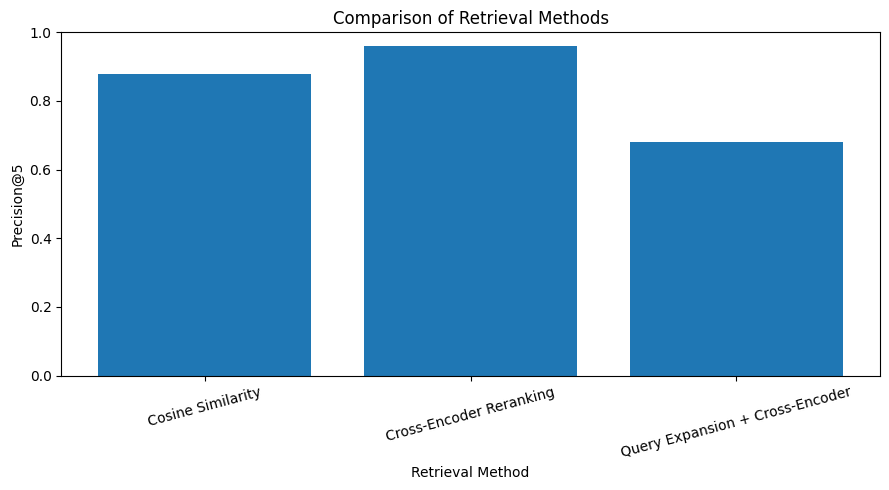

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Method"],
    comparison["Precision@5"]
)

plt.ylabel("Precision@5")
plt.xlabel("Retrieval Method")
plt.title("Comparison of Retrieval Methods")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


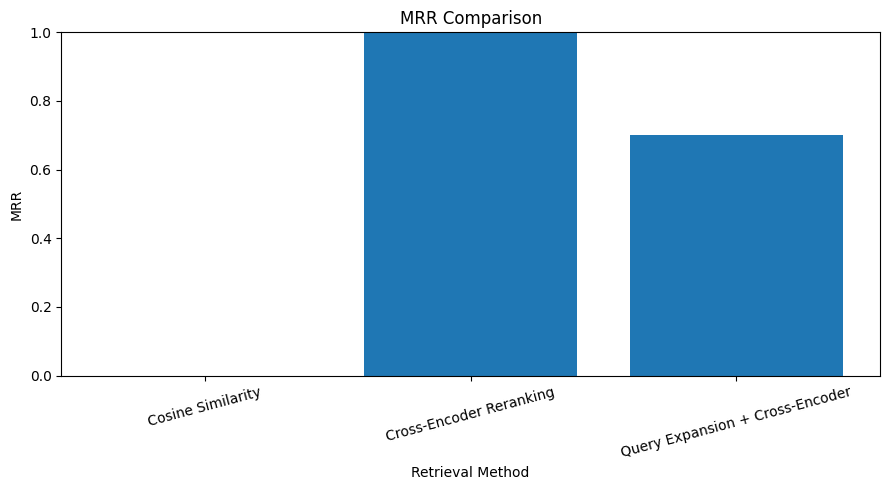

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Method"],
    comparison["MRR"].fillna(0)
)

plt.ylabel("MRR")
plt.xlabel("Retrieval Method")
plt.title("MRR Comparison")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


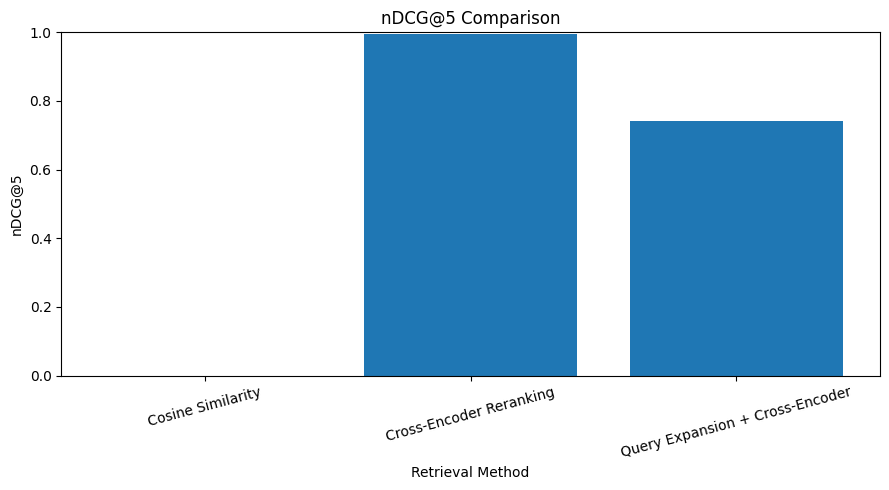

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Method"],
    comparison["nDCG@5"].fillna(0)
)

plt.ylabel("nDCG@5")
plt.xlabel("Retrieval Method")
plt.title("nDCG@5 Comparison")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Cross-Encoder reranking achieved the best overall retrieval
performance, with a Precision@5 of 0.96, MRR of 1.00,
and nDCG@5 of 0.9966.

Although query expansion was explored as an additional
retrieval enhancement, it reduced performance to a Precision@5
of 0.68, MRR of 0.70, and nDCG@5 of 0.7431. Therefore,
Cross-Encoder reranking was selected as the final retrieval
strategy.

In [ ]:
def final_search(query, candidate_k=20, top_k=5):

    # 1. Encode user query
    query_embedding = model.encode([query])

    # 2. Retrieve candidates using cosine similarity
    similarities = cosine_similarity(
        query_embedding,
        clean_embeddings
    )[0]

    candidate_indices = similarities.argsort()[::-1][:candidate_k]

    candidates = df_clean.iloc[candidate_indices].copy()

    # 3. Cross-Encoder reranking
    pairs = [
        [query, text]
        for text in candidates["text"]
    ]

    rerank_scores = reranker.predict(pairs)

    candidates["rerank_score"] = rerank_scores

    # 4. Sort by Cross-Encoder score
    candidates = candidates.sort_values(
        "rerank_score",
        ascending=False
    )

    # 5. Return final recommendations
    return candidates.head(top_k)


In [126]:
results = final_search(
    "RAG applications in healthcare and medical diagnosis"
)

print(
    results[
        [
            "title",
            "year",
            "citations",
            "cluster_name",
            "rerank_score"
        ]
    ].to_string(index=False)
)


                                                                                                                                             title  year  citations                cluster_name  rerank_score
                                                                 Enhancing medical AI with retrieval-augmented generation: A mini narrative review  2025         79 Healthcare & Biomedical RAG      7.470868
                                                                        Retrieval-Augmented Generation (RAG) in Healthcare: A Comprehensive Review  2025         60 Healthcare & Biomedical RAG      6.281657
                Improving Large Language Model Applications in the Medical and Nursing Domains With Retrieval-Augmented Generation: Scoping Review  2025         22 Healthcare & Biomedical RAG      4.167648
         Bridging AI and Healthcare: A Scoping Review of Retrieval-Augmented Generation—Ethics, Bias, Transparency, Improvements, and Applications  2025         15 Healthcare &

In [127]:
queries = [
    "RAG applications in healthcare and medical diagnosis",
    "retrieval augmented generation for cybersecurity",
    "RAG applications in education",
    "evaluation methods for RAG systems",
    "knowledge graph based retrieval augmented generation"
]

for query in queries:

    print("\n" + "=" * 80)
    print("QUERY:", query)
    print("=" * 80)

    results = final_search(query)

    print(
        results[
            [
                "title",
                "year",
                "citations",
                "cluster_name",
                "rerank_score"
            ]
        ].to_string(index=False)
    )



QUERY: RAG applications in healthcare and medical diagnosis
                                                                                                                                             title  year  citations                cluster_name  rerank_score
                                                                 Enhancing medical AI with retrieval-augmented generation: A mini narrative review  2025         79 Healthcare & Biomedical RAG      7.470868
                                                                        Retrieval-Augmented Generation (RAG) in Healthcare: A Comprehensive Review  2025         60 Healthcare & Biomedical RAG      6.281657
                Improving Large Language Model Applications in the Medical and Nursing Domains With Retrieval-Augmented Generation: Scoping Review  2025         22 Healthcare & Biomedical RAG      4.167648
         Bridging AI and Healthcare: A Scoping Review of Retrieval-Augmented Generation—Ethics, Bias, Transparency,